In [1]:
# Color-Based Climbing Hold Segmentation
# This notebook demonstrates basic color segmentation for climbing holds

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from collections import Counter
import os

try:
    from skimage.feature import local_binary_pattern
    HAS_LBP = True
except ImportError:
    print("Warning: scikit-image not available. Some texture features will be limited.")
    HAS_LBP = False

try:
    from skimage.measure import regionprops
    HAS_REGIONPROPS = True
except ImportError:
    HAS_REGIONPROPS = False

try:
    from scipy import ndimage
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

plt.rcParams['figure.figsize'] = (12, 8)

def load_and_display_image(image_path):
    """Load an image and display it"""
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load image from {image_path}")
        return None
    
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Display original image
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title('Original Climbing Wall Image')
    plt.axis('off')
    plt.show()
    
    return img, img_rgb

def extract_dominant_colors(image, k=8):
    """Extract dominant colors from the image using K-means clustering"""
    # Reshape image to be a list of pixels
    data = image.reshape((-1, 3))
    data = np.float32(data)
    
    # Apply K-means clustering
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(data, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    # Convert back to uint8 and get the color palette
    centers = np.uint8(centers)
    
    # Count the frequency of each cluster
    label_counts = Counter(labels.flatten())
    
    # Create color palette visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Show original image
    ax1.imshow(image)
    ax1.set_title('Original Image')
    ax1.axis('off')
    
    # Show color palette
    palette_height = 100
    palette_width = 50
    palette = np.zeros((palette_height, palette_width * k, 3), dtype=np.uint8)
    
    for i, center in enumerate(centers):
        palette[:, i*palette_width:(i+1)*palette_width] = center
    
    ax2.imshow(palette)
    ax2.set_title(f'Dominant Colors (K={k})')
    ax2.axis('off')
    
    # Add color values as text
    for i, (center, count) in enumerate(zip(centers, [label_counts[i] for i in range(k)])):
        percentage = (count / len(labels)) * 100
        ax2.text(i*palette_width + palette_width//2, palette_height//2, 
                f'RGB: {center}\n{percentage:.1f}%', 
                ha='center', va='center', fontsize=8, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    return centers, labels.reshape(image.shape[:2])

def create_color_mask(image, target_color, tolerance=50):
    """Create a mask for a specific color with tolerance"""
    # Convert to HSV for better color segmentation
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    target_hsv = cv2.cvtColor(np.uint8([[target_color]]), cv2.COLOR_RGB2HSV)[0][0]
    
    # Convert values to int to avoid overflow warnings
    h, s, v = int(target_hsv[0]), int(target_hsv[1]), int(target_hsv[2])
    
    # Handle red color wrap-around in HSV (red is at 0 and 180)
    if target_color[0] > 200 and target_color[1] < 100 and target_color[2] < 100:  # Pure red detection
        # Red wraps around in HSV, so we need two ranges
        lower_red1 = np.array([0, 50, 50])
        upper_red1 = np.array([10, 255, 255])
        lower_red2 = np.array([170, 50, 50])
        upper_red2 = np.array([179, 255, 255])
        
        mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
        mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
        mask = cv2.bitwise_or(mask1, mask2)
    else:
        # For other colors, use normal range
        lower_bound = np.array([max(0, target_hsv[0] - tolerance//3), 50, 50])
        upper_bound = np.array([min(179, target_hsv[0] + tolerance//3), 255, 255])
        
        mask = cv2.inRange(hsv, lower_bound, upper_bound)
    
    return mask

def segment_holds_by_color(image, target_colors, tolerance=50):
    """Segment climbing holds by specific colors"""
    fig, axes = plt.subplots(2, len(target_colors), figsize=(4*len(target_colors), 8))
    if len(target_colors) == 1:
        axes = axes.reshape(2, 1)
    
    masks = []
    
    for i, color in enumerate(target_colors):
        # Create mask for this color
        mask = create_color_mask(image, color, tolerance)
        
        # Apply morphological operations to clean up the mask
        kernel = np.ones((5,5), np.uint8)
        mask_cleaned = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_CLOSE, kernel)
        
        # Apply mask to original image
        segmented = image.copy()
        segmented[mask_cleaned == 0] = [0, 0, 0]  # Make non-target areas black
        
        # Display results
        axes[0, i].imshow(mask_cleaned, cmap='gray')
        axes[0, i].set_title(f'Mask for Color {i+1}\nRGB: {color}')
        axes[0, i].axis('off')
        
        axes[1, i].imshow(segmented)
        axes[1, i].set_title(f'Segmented Holds')
        axes[1, i].axis('off')
        
        masks.append(mask_cleaned)
    
    plt.tight_layout()
    plt.show()
    
    return masks

def extract_texture_features(image_region):
    """Extract texture features from an image region using LBP and alternative methods"""
    # Convert to grayscale if needed
    if len(image_region.shape) == 3:
        gray = cv2.cvtColor(image_region, cv2.COLOR_RGB2GRAY)
    else:
        gray = image_region
    
    # Ensure minimum size for analysis
    if gray.shape[0] < 10 or gray.shape[1] < 10:
        return None
    
    features = {}
    
    # 1. Local Binary Pattern (LBP) for texture
    try:
        radius = min(3, min(gray.shape) // 6)  # Adaptive radius
        n_points = 8 * radius
        lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
        
        # LBP histogram features
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_points + 2, range=(0, n_points + 2))
        lbp_hist = lbp_hist.astype(float)
        lbp_hist /= (lbp_hist.sum() + 1e-7)  # Normalize
        
        features['lbp_uniformity'] = np.sum(lbp_hist ** 2)  # Uniformity measure
        features['lbp_entropy'] = -np.sum(lbp_hist * np.log(lbp_hist + 1e-7))  # Entropy
    except:
        # Fallback LBP features
        features['lbp_uniformity'] = 0.5
        features['lbp_entropy'] = 1.0
    
    # 2. Alternative texture measures (instead of GLCM if not available)
    try:
        # Try to import and use GLCM
        from skimage.feature import greycomatrix, greycoprops
        
        # Resize if too large for GLCM computation
        if gray.shape[0] > 100 or gray.shape[1] > 100:
            gray_small = cv2.resize(gray, (min(100, gray.shape[1]), min(100, gray.shape[0])))
        else:
            gray_small = gray
        
        # Scale to reduce GLCM computation time
        gray_scaled = (gray_small / 32).astype(int)  # Scale to 0-7 range
        
        glcm = greycomatrix(gray_scaled, distances=[1], angles=[0, 45, 90, 135], 
                           levels=8, symmetric=True, normed=True)
        
        # Extract GLCM properties
        features['glcm_contrast'] = np.mean(greycoprops(glcm, 'contrast'))
        features['glcm_dissimilarity'] = np.mean(greycoprops(glcm, 'dissimilarity'))
        features['glcm_homogeneity'] = np.mean(greycoprops(glcm, 'homogeneity'))
        features['glcm_energy'] = np.mean(greycoprops(glcm, 'energy'))
        
    except ImportError:
        print("Note: GLCM not available, using alternative texture measures")
        # Alternative texture measures using basic OpenCV/numpy operations
        
        # Gradient-based texture measures
        grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
        
        features['glcm_contrast'] = np.std(gradient_magnitude)  # Approximates contrast
        features['glcm_dissimilarity'] = np.mean(np.abs(np.diff(gray.flatten())))
        features['glcm_homogeneity'] = 1.0 / (1.0 + features['glcm_contrast'])
        features['glcm_energy'] = np.sum(gray**2) / (gray.shape[0] * gray.shape[1])
        
    except Exception as e:
        print(f"Texture analysis error: {e}")
        # Fallback values
        features['glcm_contrast'] = 0
        features['glcm_dissimilarity'] = 0
        features['glcm_homogeneity'] = 1
        features['glcm_energy'] = 1
    
    # 3. Basic texture measures (always available)
    features['std_intensity'] = np.std(gray)
    features['mean_intensity'] = np.mean(gray)
    
    # Edge density (how much detail/texture)
    edges = cv2.Canny(gray, 50, 150)
    features['edge_density'] = np.sum(edges > 0) / (gray.shape[0] * gray.shape[1])
    
    # Additional simple texture measures
    # Variance as texture measure
    features['intensity_variance'] = np.var(gray)
    
    # Range of intensities
    features['intensity_range'] = np.max(gray) - np.min(gray)
    
    # Local variance (another texture measure)
    kernel = np.ones((5,5), np.float32) / 25
    gray_smooth = cv2.filter2D(gray.astype(np.float32), -1, kernel)
    local_var = (gray.astype(np.float32) - gray_smooth) ** 2
    features['local_variance'] = np.mean(local_var)
    
    return features

def extract_shape_features(contour, image_shape):
    features = {}

    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    if area < 10 or perimeter < 10:
        return None

    features['area'] = area
    features['perimeter'] = perimeter

    features['compactness'] = (perimeter ** 2) / (4 * np.pi * area) if area > 0 else float('inf')

    x, y, w, h = cv2.boundingRect(contour)
    features['aspect_ratio'] = float(w) / h if h > 0 else 1
    features['bbox_area'] = w * h
    features['extent'] = area / (w * h) if (w * h) > 0 else 0

    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    features['solidity'] = area / hull_area if hull_area > 0 else 0

    features['equivalent_diameter'] = np.sqrt(4 * area / np.pi)

    img_area = image_shape[0] * image_shape[1]
    features['relative_size'] = area / img_area

    moments = cv2.moments(contour)
    if moments['m00'] != 0:
        hu_moments = cv2.HuMoments(moments)
        for i, hu in enumerate(hu_moments.flatten()):
            features[f'hu_moment_{i}'] = -np.sign(hu) * np.log10(abs(hu) + 1e-10)

    return features

def analyze_potential_holds(image, masks, colors, min_area=500):

    all_candidates = []

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    for color_idx, (mask, color) in enumerate(zip(masks, colors)):

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour_idx, contour in enumerate(contours):
            if cv2.contourArea(contour) < min_area:
                continue

            x, y, w, h = cv2.boundingRect(contour)

            contour_mask = np.zeros(mask.shape, dtype=np.uint8)
            cv2.fillPoly(contour_mask, [contour], 255)

            region_rgb = image[y:y+h, x:x+w]
            region_mask = contour_mask[y:y+h, x:x+w]
            region_gray = gray[y:y+h, x:x+w]

            if region_rgb.shape[0] < 10 or region_rgb.shape[1] < 10:
                continue

            candidate = {
                'color_group': color_idx,
                'contour_id': contour_idx,
                'bbox': (x, y, w, h),
                'center': (x + w//2, y + h//2),
                'target_color': color,
            }

            shape_features = extract_shape_features(contour, image.shape)
            if shape_features:
                candidate.update(shape_features)

            texture_features = extract_texture_features(region_rgb)
            if texture_features:
                candidate.update(texture_features)

            mask_3d = np.stack([region_mask, region_mask, region_mask], axis=-1)
            masked_pixels = region_rgb[mask_3d > 0].reshape(-1, 3)
            
            if len(masked_pixels) > 0:
                actual_color = np.mean(masked_pixels, axis=0)
                candidate['actual_color'] = actual_color.tolist()
                candidate['color_distance'] = np.linalg.norm(actual_color - np.array(color))
            else:
                # Fallback to mean color of entire region if mask fails
                actual_color = np.mean(region_rgb.reshape(-1, 3), axis=0)
                candidate['actual_color'] = actual_color.tolist()
                candidate['color_distance'] = np.linalg.norm(actual_color - np.array(color))

            all_candidates.append(candidate)

    return all_candidates

def classify_holds(candidates, rules=None):
    """Classify candidates as likely holds or false positives using rules"""
    if rules is None:
        # Default rules based on typical climbing hold characteristics
        rules = {
            'min_area': 200,
            'max_area': 50000,
            'max_compactness': 5.0,  # Not too elongated
            'min_solidity': 0.3,     # Not too concave
            'max_aspect_ratio': 4.0, # Not too thin
            'min_extent': 0.2,       # Fills reasonable portion of bounding box
            'max_color_distance': 100, # Color should be reasonably close to target
            'min_edge_density': 0.01,  # Should have some texture/detail
        }
    
    classified = []
    
    for candidate in candidates:
        score = 0
        reasons = []
        
        # Area check
        if rules['min_area'] <= candidate.get('area', 0) <= rules['max_area']:
            score += 2
            reasons.append("Good size")
        else:
            reasons.append(f"Size issue: {candidate.get('area', 0):.0f}")
        
        # Shape checks
        if candidate.get('compactness', float('inf')) <= rules['max_compactness']:
            score += 1
            reasons.append("Good compactness")
        
        if candidate.get('solidity', 0) >= rules['min_solidity']:
            score += 1
            reasons.append("Good solidity")
        
        if candidate.get('aspect_ratio', float('inf')) <= rules['max_aspect_ratio']:
            score += 1
            reasons.append("Good aspect ratio")
        
        if candidate.get('extent', 0) >= rules['min_extent']:
            score += 1
            reasons.append("Good extent")
        
        # Color check
        if candidate.get('color_distance', float('inf')) <= rules['max_color_distance']:
            score += 2
            reasons.append("Good color match")
        else:
            reasons.append(f"Color mismatch: {candidate.get('color_distance', 0):.1f}")
        
        # Texture check
        if candidate.get('edge_density', 0) >= rules['min_edge_density']:
            score += 1
            reasons.append("Has texture")
        
        # Classification
        if score >= 6:
            classification = "Likely Hold"
        elif score >= 4:
            classification = "Possible Hold"
        else:
            classification = "Unlikely Hold"
        
        candidate['classification'] = classification
        candidate['confidence_score'] = score
        candidate['reasons'] = reasons
        
        classified.append(candidate)
    
    return classified

def visualize_enhanced_detection(image, classified_candidates):
    """Visualize holds with classification and features"""
    result = image.copy()
    
    # Color coding for classifications
    colors = {
        "Likely Hold": (0, 255, 0),      # Green
        "Possible Hold": (255, 165, 0),   # Orange  
        "Unlikely Hold": (255, 0, 0)     # Red
    }
    
    # Group by classification
    by_class = {}
    for candidate in classified_candidates:
        class_name = candidate['classification']
        if class_name not in by_class:
            by_class[class_name] = []
        by_class[class_name].append(candidate)
    
    # Draw bounding boxes and labels
    for candidate in classified_candidates:
        x, y, w, h = candidate['bbox']
        class_name = candidate['classification']
        score = candidate['confidence_score']
        
        color = colors.get(class_name, (128, 128, 128))
        
        # Draw bounding box
        cv2.rectangle(result, (x, y), (x+w, y+h), color, 2)
        
        # Draw label
        label = f"{class_name} ({score}/8)"
        cv2.putText(result, label, (x, y-10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    
    # Display results
    plt.figure(figsize=(15, 10))
    plt.imshow(result)
    plt.title(f'Enhanced Hold Detection Results')
    plt.axis('off')
    
    # Add legend
    legend_text = []
    for class_name, candidates in by_class.items():
        count = len(candidates)
        legend_text.append(f"{class_name}: {count}")
    
    plt.figtext(0.02, 0.02, '\n'.join(legend_text), fontsize=12, 
                bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))
    
    plt.show()
    
    return by_class

def print_detailed_analysis(classified_candidates):
    """Print detailed analysis of detected holds"""
    print("=== Detailed Hold Analysis ===\n")
    
    for i, candidate in enumerate(classified_candidates):
        print(f"Candidate {i+1}: {candidate['classification']}")
        print(f"  Confidence Score: {candidate['confidence_score']}/8")
        print(f"  Position: {candidate['center']}")
        print(f"  Size: {candidate.get('area', 0):.0f} pixels")
        print(f"  Shape - Compactness: {candidate.get('compactness', 0):.2f}, "
              f"Solidity: {candidate.get('solidity', 0):.2f}")
        print(f"  Color Distance: {candidate.get('color_distance', 0):.1f}")
        print(f"  Edge Density: {candidate.get('edge_density', 0):.3f}")
        print(f"  Reasons: {', '.join(candidate['reasons'])}")
        print()

# Enhanced main workflow
def enhanced_climbing_analysis(image_path, target_colors=None, tolerance=50, 
                             min_hold_area=500, classification_rules=None):
    """Complete enhanced workflow for climbing wall analysis"""
    
    print("=== Enhanced Climbing Wall Analysis ===")
    
    # Step 1: Load image
    print("1. Loading image...")
    img, img_rgb = load_and_display_image(image_path)
    if img is None:
        return
    
    # Step 2: Extract dominant colors if needed
    if target_colors is None:
        print("2. Extracting dominant colors...")
        dominant_colors, color_labels = extract_dominant_colors(img_rgb, k=8)
        target_colors = quick_test_with_sample_colors()
    
    # Step 3: Color segmentation
    print("3. Performing color segmentation...")
    masks = segment_holds_by_color(img_rgb, target_colors, tolerance)
    
    # Step 4: Multi-feature analysis
    print("4. Analyzing texture and shape features...")
    candidates = analyze_potential_holds(img_rgb, masks, target_colors, min_hold_area)
    
    # Step 5: Classification
    print("5. Classifying candidates...")
    classified = classify_holds(candidates, classification_rules)
    
    # Step 6: Visualization
    print("6. Visualizing results...")
    results_by_class = visualize_enhanced_detection(img_rgb, classified)
    
    # Step 7: Detailed analysis
    print_detailed_analysis(classified)
    
    return classified, results_by_class
    
# Example usage and testing functions
def quick_test_with_sample_colors():
    """Quick test with common climbing hold colors"""
    # Common climbing hold colors (RGB values)
    test_colors = [
        [220, 20, 20],   # Darker red (pure red often doesn't work well)
        [0, 255, 0],   # Green  
        [0, 0, 255],   # Blue
        [255, 255, 0],  # Yellow
        [255, 0, 255],  # Magenta/Purple
        [0, 255, 255],  # Cyan
    ]
    
    print("Common climbing hold colors to look for:")
    for i, color in enumerate(test_colors):
        print(f"Color {i+1}: RGB{color}")
    
    return test_colors

def debug_color_detection(image, target_color, tolerance_range=[30, 50, 70, 90]):
    """Debug function to test different tolerance values for a specific color"""
    print(f"Testing color detection for RGB: {target_color}")
    
    fig, axes = plt.subplots(2, len(tolerance_range), figsize=(4*len(tolerance_range), 8))
    
    for i, tol in enumerate(tolerance_range):
        mask = create_color_mask(image, target_color, tol)
        
        # Apply mask to original image
        segmented = image.copy()
        segmented[mask == 0] = [0, 0, 0]
        
        axes[0, i].imshow(mask, cmap='gray')
        axes[0, i].set_title(f'Mask (tolerance={tol})')
        axes[0, i].axis('off')
        
        axes[1, i].imshow(segmented)
        axes[1, i].set_title(f'Segmented (tolerance={tol})')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

def interactive_color_picker(image):
    """Interactive function to help pick colors from the image"""
    print("=== Interactive Color Picker ===")
    print("This will help you find the exact RGB values of holds in your image")
    
    # Show image with grid for easier coordinate picking
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image)
    ax.set_title('Click on holds to get their RGB values\n(Note: This is just for visualization - use print statements below)')
    ax.grid(True, alpha=0.3)
    
    # Add instructions for manual color picking
    height, width = image.shape[:2]
    
    print("\nTo manually pick colors:")
    print("1. Look at the image above")
    print("2. Estimate coordinates of a hold you want to detect")
    print("3. Use the function below to get RGB values:")
    print("\n# Example usage:")
    print("# get_pixel_color(image, x=100, y=200)  # Replace with actual coordinates")
    
    plt.show()
    
    return image

def get_pixel_color(image, x, y):
    """Get RGB color at specific pixel coordinates"""
    if 0 <= y < image.shape[0] and 0 <= x < image.shape[1]:
        color = image[y, x]  # Note: image indexing is [row, col] = [y, x]
        print(f"RGB color at ({x}, {y}): {color}")
        return color.tolist()
    else:
        print(f"Coordinates ({x}, {y}) are outside image bounds")
        return None

# Main workflow function
def analyze_climbing_wall(image_path, target_colors=None, tolerance=50, min_hold_area=500):
    """Complete workflow for analyzing a climbing wall image"""
    
    print("=== Climbing Wall Analysis ===")
    
    # Step 1: Load image
    print("1. Loading image...")
    img, img_rgb = load_and_display_image(image_path)
    if img is None:
        return
    
    # Step 2: Extract dominant colors if no target colors specified
    if target_colors is None:
        print("2. Extracting dominant colors...")
        dominant_colors, color_labels = extract_dominant_colors(img_rgb, k=8)
        print("Choose colors from the palette above for hold segmentation")
        target_colors = quick_test_with_sample_colors()
    
    # Step 3: Segment holds by color
    print("3. Segmenting holds by color...")
    masks = segment_holds_by_color(img_rgb, target_colors, tolerance)
    
    # Step 4: Detect individual holds
    print("4. Detecting individual holds...")
    holds_info = visualize_detected_holds(img_rgb, masks, target_colors, min_hold_area)
    
    print(f"\n=== Results ===")
    print(f"Total holds detected: {len(holds_info)}")
    # for hold in holds_info:
    #     print(f"Color Group {hold['color_group']}, Hold {hold['hold_id']}: "
    #           f"Center at {hold['center']}, Area: {hold['area']:.0f} pixels")
    
    return holds_info

# Legacy functions maintained for compatibility
def detect_hold_contours(mask, min_area=500):
    """Detect individual holds from a color mask (legacy function)"""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
    return valid_contours

def visualize_detected_holds(image, masks, colors, min_area=500):
    """Visualize detected holds with bounding boxes (legacy function)"""
    result = image.copy()
    all_holds_info = []
    
    for i, (mask, color) in enumerate(zip(masks, colors)):
        contours = detect_hold_contours(mask, min_area)
        
        for j, contour in enumerate(contours):
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(result, (x, y), (x+w, y+h), color[::-1], 3)
            cv2.putText(result, f'Hold_{i+1}_{j+1}', (x, y-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color[::-1], 2)
            
            hold_info = {
                'color_group': i+1,
                'hold_id': j+1,
                'bbox': (x, y, w, h),
                'area': cv2.contourArea(contour),
                'center': (x + w//2, y + h//2)
            }
            all_holds_info.append(hold_info)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(result)
    plt.title(f'Detected Holds (Total: {len(all_holds_info)})')
    plt.axis('off')
    plt.show()
    
    return all_holds_info

KeyboardInterrupt: 

=== Enhanced Climbing Wall Analysis ===
1. Loading image...


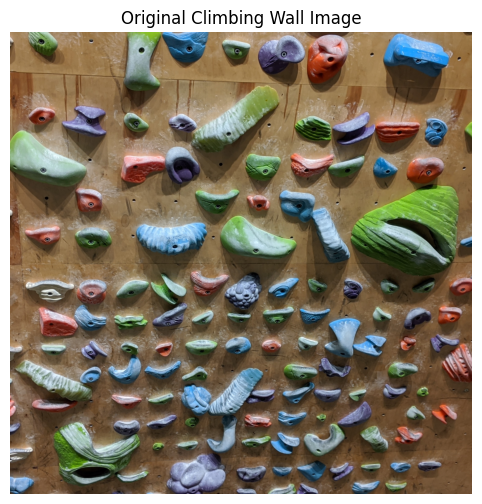

2. Extracting dominant colors...


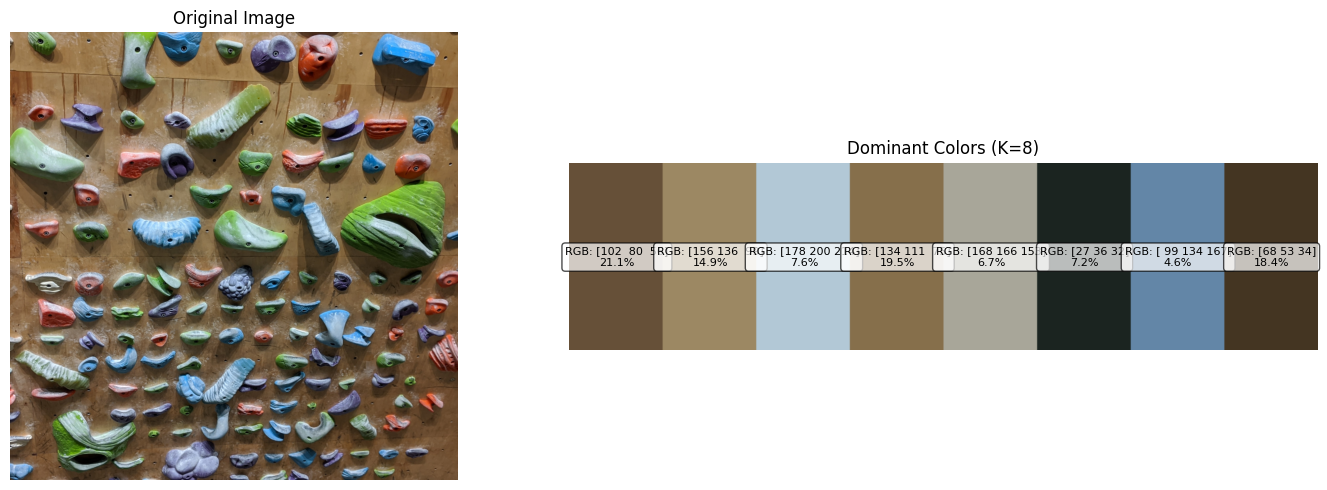

Common climbing hold colors to look for:
Color 1: RGB[220, 20, 20]
Color 2: RGB[0, 255, 0]
Color 3: RGB[0, 0, 255]
Color 4: RGB[255, 255, 0]
Color 5: RGB[255, 0, 255]
Color 6: RGB[0, 255, 255]
3. Performing color segmentation...


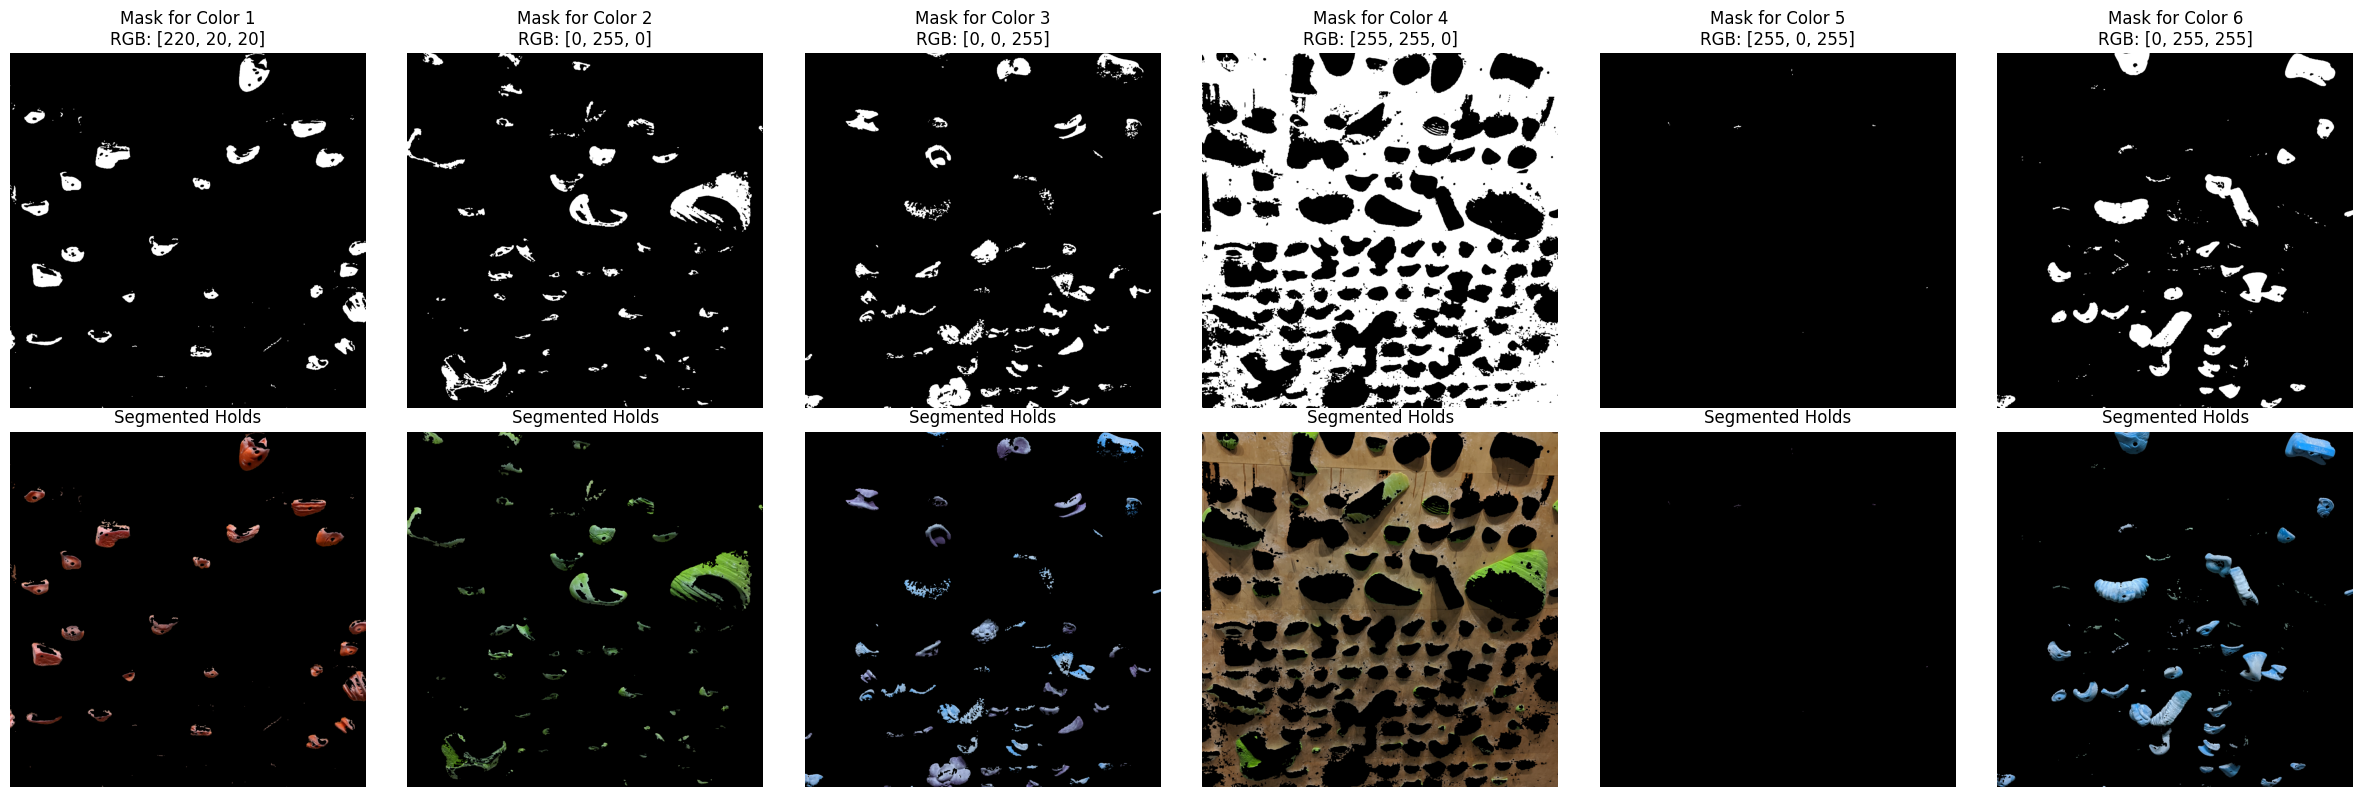

4. Analyzing texture and shape features...
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternative texture measures
Note: GLCM not available, using alternativ

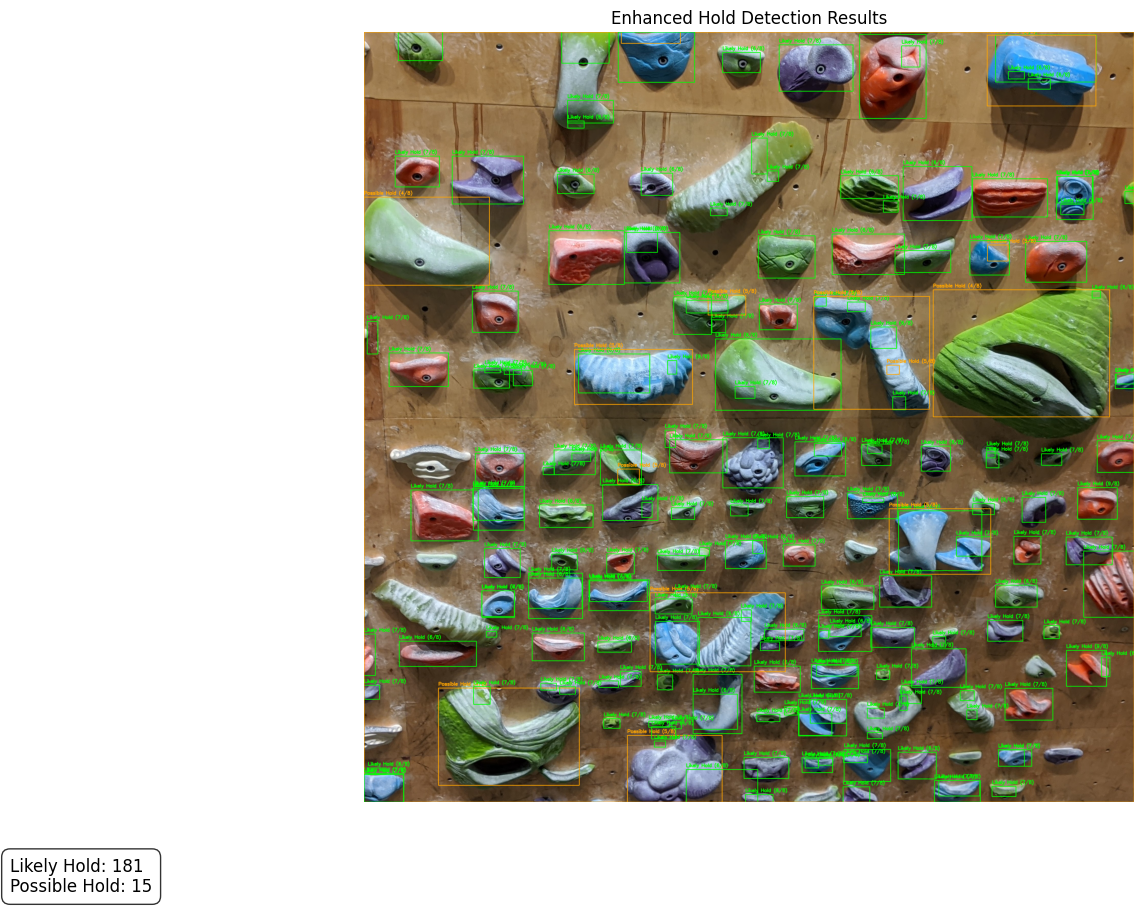

=== Detailed Hold Analysis ===

Candidate 1: Likely Hold
  Confidence Score: 7/8
  Position: (2611, 2639)
  Size: 12206 pixels
  Shape - Compactness: 4.40, Solidity: 0.72
  Color Distance: 113.8
  Edge Density: 0.080
  Reasons: Good size, Good compactness, Good solidity, Good aspect ratio, Good extent, Color mismatch: 113.8, Has texture

Candidate 2: Likely Hold
  Confidence Score: 6/8
  Position: (1622, 2541)
  Size: 8644 pixels
  Shape - Compactness: 6.02, Solidity: 0.60
  Color Distance: 120.2
  Edge Density: 0.126
  Reasons: Good size, Good solidity, Good aspect ratio, Good extent, Color mismatch: 120.2, Has texture

Candidate 3: Likely Hold
  Confidence Score: 6/8
  Position: (2912, 2493)
  Size: 606 pixels
  Shape - Compactness: 5.59, Solidity: 0.48
  Color Distance: 145.8
  Edge Density: 0.032
  Reasons: Good size, Good solidity, Good aspect ratio, Good extent, Color mismatch: 145.8, Has texture

Candidate 4: Likely Hold
  Confidence Score: 9/8
  Position: (2837, 2498)
  Size: 1

In [12]:
classified_holds, results = enhanced_climbing_analysis('C:/Users/0fore/Downloads/test_wall.jpg')
# Access results by classification
likely_holds = results.get('Likely Hold', [])
possible_holds = results.get('Possible Hold', [])
unlikely_holds = results.get('Unlikely Hold', [])

print(f"Found {len(likely_holds)} likely holds")

# Analyze specific features
for hold in likely_holds:
    print(f"Hold at {hold['center']}: confidence {hold['confidence_score']}/8")
    print(f"Texture: edge_density={hold.get('edge_density', 0):.3f}")
    print(f"Shape: compactness={hold.get('compactness', 0):.2f}")